In [1]:
from dataclasses import dataclass, field
import json
import math
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
# import statistics
from tqdm import tqdm

from modules import plotting, utils, expeval

In [22]:
import importlib
importlib.reload(expeval)

<module 'modules.expeval' from '/home/matthis/PhD/genomegraph/learn_specific_profiles/modules/expeval.py'>

In [3]:
_basepath = None
for bp in [Path("/home/ebelm/genomegraph/"),
           Path("/home/matthis/PhD/mnt/brain/genomegraph/"),
           Path("/home/ebelm/brain/genomegraph/"),]:
    if bp.exists():
        _basepath = bp
        break
if _basepath is None:
    raise RuntimeError("Could not find base path.")

wd = _basepath / "runs/20251125_compare_implementations_on_STREME_vs_ProfileFinding"
datadir = _basepath / "data/20250408_STREME_benchmark_revisited"

In [4]:
Ref_Full = pd.read_csv(datadir / "target_reference_motifs.tsv", sep="\t", names=["file", "motif"])
Ref_Hyb = pd.read_csv(datadir / "target_reference_motifs_hybrid.tsv", sep="\t", names=["file", "motif"])
Ref_Sim = pd.read_csv(datadir / "target_reference_motifs_simulated.tsv", sep="\t", names=["file", "motif"])
Ref_Motifs = utils.readMemeFile(datadir / "jolma2013.meme", list(set(list(Ref_Full["motif"].values) +
                                                                     list(Ref_Hyb["motif"].values) +
                                                                     list(Ref_Sim["motif"].values))))

In [5]:
# load all runs
results = {}
experiments_dict = { # track all available experiment directories as a table, available == successfully run
    "implementation": [],
    "setting": [],
    "subdir": [],
    "experiment": [],
    "streme": [],
    "profilefinding": [],
    "profilefinding_init": []
}
for impl in ["legacy_Z", "new_Z"]:
    results[impl] = {}
    for setting, subdir_list in {
        "full": [None], 
        "diluted": [f"{d:.2f}" for d in [0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99, 1]], 
        "hybrid": [f"{i:02d}" for i in range(20)], 
        "simulated": [f"order_0/wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak/{c/10:.2f}" for c in range(11)]}.items():
        
        if subdir_list[0] is not None:
            results[impl][setting] = {}

        for subdir in subdir_list:
            rundir = wd / impl / setting / subdir if subdir is not None else wd / impl / setting
            assert rundir.exists(), f"Run directory {rundir} does not exist."
            srresult = expeval.load_single_run(
                rundir,
                require_profileFinding=True,
                require_streme=False,
                require_profileFinding_init=True,
                allow_failed=True
            )

            if subdir is not None:
                results[impl][setting][subdir] = srresult
            else:
                results[impl][setting] = srresult

            experiments = sorted(set(srresult.streme.experiment + srresult.profilefinding.experiment + 
                                     srresult.profilefinding_init.experiment))
            if len(experiments) > 0:
                for experiment in experiments:            
                    experiments_dict["implementation"].append(impl)
                    experiments_dict["setting"].append(setting)
                    experiments_dict["subdir"].append(subdir)
                    experiments_dict["experiment"].append(experiment)
                    experiments_dict["streme"].append(
                        experiment in srresult.streme.experiment
                    )
                    experiments_dict["profilefinding"].append(
                        experiment in srresult.profilefinding.experiment
                    )
                    experiments_dict["profilefinding_init"].append(
                        experiment in srresult.profilefinding_init.experiment
                    )

experiments_df = pd.DataFrame(experiments_dict)
print(experiments_df)

[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20251125_compare_implementations_on_STREME_vs_ProfileFinding/legacy_Z/full/wgEncodeAwgTfbsHaibK562SrfV0416101UniPk.narrowPeak/profilefinding_init/tomtom/tomtom.tsv, returning -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20251125_compare_implementations_on_STREME_vs_ProfileFinding/legacy_Z/full/wgEncodeAwgTfbsHaibK562Tead4sc101184V0422111UniPk.narrowPeak/profilefinding/tomtom/tomtom.tsv, returning -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20251125_compare_implementations_on_STREME_vs_ProfileFinding/legacy_Z/full/wgEncodeAwgTfbsHaibK562Tead4sc101184V0422111UniPk.narrowPeak/profilefinding_init/tomtom/tomtom.tsv, returning -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20251125_compare_implementations_on_STREME_vs_ProfileFinding/legacy_Z/full/wgEncodeAw

In [19]:
# Add STREME results from previous experiment run for comparison
results_streme = {}
for setting in results["new_Z"].keys():
    if setting == "simulated":
        streme_wd = _basepath / "runs" / "20250430_simulated_STREME_vs_ProfileFinding"
    else:
        streme_wd = _basepath / "runs" / "20250408_repeat_STREME_vs_ProfileFinding" / setting

    subdir_list = [None] if setting == "full" else list(results["new_Z"][setting].keys())
    if subdir_list[0] is not None:
        results_streme[setting] = {}

    for subdir in subdir_list:
        rundir = streme_wd / subdir if subdir is not None else streme_wd
        assert rundir.exists(), f"Run directory {rundir} does not exist."
        srresult = expeval.load_single_run(
            rundir,
            require_streme=True,
            require_profileFinding=False,
            require_profileFinding_init=False,
            allow_failed=True
        )
        if subdir is not None:
            results_streme[setting][subdir] = srresult
        else:
            results_streme[setting] = srresult

[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250408_repeat_STREME_vs_ProfileFinding/full/wgEncodeAwgTfbsHaibK562SrfV0416101UniPk.narrowPeak/profilefinding_init/tomtom/tomtom.tsv, returning -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250408_repeat_STREME_vs_ProfileFinding/full/wgEncodeAwgTfbsHaibK562Tead4sc101184V0422111UniPk.narrowPeak/profilefinding/tomtom/tomtom.tsv, returning -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250408_repeat_STREME_vs_ProfileFinding/full/wgEncodeAwgTfbsHaibK562Tead4sc101184V0422111UniPk.narrowPeak/profilefinding_init/tomtom/tomtom.tsv, returning -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250408_repeat_STREME_vs_ProfileFinding/full/wgEncodeAwgTfbsSydhK562Atf3UniPk.narrowPeak/streme/tomtom/tomtom.tsv, returning -1 as ppval!
[WARNING] >>> Empty tomtom result

In [6]:
# plot and store comparisons for all experiments (commented to avoid long runtime, does not need to be run every time)
for setting, ref_df in {"full": Ref_Full, "diluted": Ref_Full, "hybrid": Ref_Hyb, "simulated": Ref_Sim}.items():
    print(f"Processing setting: {setting}")
    print(" Loading reference motifs...")
    motifs = {}
    for row in tqdm(ref_df.itertuples(), total=len(ref_df.index)):
        experiment = row.file
        ref = row.motif
        refmotif = expeval.TrainedMotif(
            motif=Ref_Motifs[ref],
            shift=0,
            ppval=-1,
            motifname=f"reference {ref}"
        )
        motifs[experiment] = refmotif

    assert setting in experiments_df["setting"].values, f"Setting {setting} not found in experiments."
    experiments_subdf = experiments_df[experiments_df["setting"] == setting]

    for row in tqdm(experiments_subdf.itertuples(), total=len(experiments_subdf.index), 
                    desc=f" Processing experiments for setting {setting}"):
        impl = row.implementation
        subdir = row.subdir
        experiment = row.experiment
        assert experiment in motifs, f"Experiment {experiment} not found in reference motifs."
        motifs_list = [motifs[experiment]]
        expdir = (wd / impl / setting / experiment) if subdir is None else (wd / impl / setting / subdir / experiment)
        assert expdir.exists(), f"Experiment directory {expdir} does not exist."
        assert row.profilefinding or row.profilefinding_init, \
            f"No ProfileFinding results found for experiment {experiment} in implementation {impl}, setting {setting}."
        outdir = (wd / "evaluation" / impl / setting / experiment) if subdir is None \
                    else (wd / "evaluation" / impl / setting / subdir / experiment)
        outdir.mkdir(exist_ok=True, parents=True)
        # ====== Avoid re-computing if file already exists ======
        if (outdir / "compare_motifs.png").is_file():
            continue
        # =======================================================

        if row.profilefinding:
            pf_motif = expeval.load_trained_motif(expdir / "profilefinding")
            pf_motif.motifname = "pf "+pf_motif.motifname
            motifs_list = [pf_motif] + motifs_list
        if row.profilefinding_init:
            pf_init_motif = expeval.load_trained_motif(expdir / "profilefinding_init")
            pf_init_motif.motifname = "pf_init "+pf_init_motif.motifname
            motifs_list.append(pf_init_motif)

        try:
            expeval.compare_motifs(motifs_list, 
                                   outdir / "compare_motifs.png", 
                                   show=False,
                                   overwrite=False)
        except AssertionError as e:
            print(f"[WARNING] >>> {e}")
            

Processing setting: full
 Loading reference motifs...


 Processing experiments for setting full: 100%|██████████| 80/80 [00:01<00:00, 70.49it/s]


Processing setting: diluted
 Loading reference motifs...


 Processing experiments for setting diluted: 100%|██████████| 1040/1040 [00:14<00:00, 70.99it/s]


Processing setting: hybrid
 Loading reference motifs...


 Processing experiments for setting hybrid: 100%|██████████| 840/840 [00:11<00:00, 74.00it/s]


Processing setting: simulated
 Loading reference motifs...


 Processing experiments for setting simulated: 100%|██████████| 22/22 [00:00<00:00, 41.70it/s]


In [7]:
# also plot the profiles from both implementations with highest and lowest ppval against the reference
for setting, ref_df in {"full": Ref_Full, "diluted": Ref_Full, "hybrid": Ref_Hyb, "simulated": Ref_Sim}.items():
    print(f"Processing setting: {setting}")
    print(" Loading reference motifs...")
    motifs = {}
    for row in tqdm(ref_df.itertuples(), total=len(ref_df.index)):
        experiment = row.file
        ref = row.motif
        refmotif = expeval.TrainedMotif(
            motif=Ref_Motifs[ref],
            shift=0,
            ppval=-1,
            motifname=f"reference {ref}"
        )
        motifs[experiment] = refmotif

    assert setting in experiments_df["setting"].values, f"Setting {setting} not found in experiments."
    experiments_subdf = experiments_df[(experiments_df["setting"] == setting) & (experiments_df["profilefinding"])] # ignore pf-init

    # unique list of experiments
    unique_experiments_subdf = experiments_subdf[['setting', 'subdir', 'experiment']].drop_duplicates() # implementation ignored
    
    for row in tqdm(unique_experiments_subdf.itertuples(), total=len(unique_experiments_subdf.index), 
                    desc=f" Processing experiments for setting {setting}"):
        subdir = row.subdir
        # print("[DEBUG] >>> subdir:", subdir)
        experiment = row.experiment
        subdir_cond = (experiments_subdf["subdir"].isnull()) if subdir is None \
                        else (experiments_subdf["subdir"] == subdir)
        experiment_subdf = experiments_subdf[(experiments_subdf["setting"] == setting) &
                                             subdir_cond &
                                             (experiments_subdf["experiment"] == experiment)]
        assert len(experiment_subdf) > 0, \
            f"No rows found for experiment {experiment} in setting {setting}, subdir {subdir}."
        if len(experiment_subdf) < 2:
            print(f"[WARNING] >>> Experiment {experiment} in setting {setting} " \
                  + "does not have results for both implementations, skipping.")
            continue
        assert len(experiment_subdf) == 2, \
            f"More than two rows found for experiment {experiment} in setting {setting}, subdir {subdir}."

        assert experiment in motifs, f"Experiment {experiment} not found in reference motifs."

        expdir_newZ = (wd / "new_Z" / setting / experiment) if subdir is None \
                        else (wd / "new_Z" / setting / subdir / experiment)
        assert expdir_newZ.exists(), f"Experiment directory {expdir_newZ} does not exist."
        expdir_legacyZ = (wd / "legacy_Z" / setting / experiment) if subdir is None \
                        else (wd / "legacy_Z" / setting / subdir / experiment)
        assert expdir_legacyZ.exists(), f"Experiment directory {expdir_legacyZ} does not exist."
        
        outdir = (wd / "evaluation" / setting / experiment) if subdir is None \
                    else (wd / "evaluation" / setting / subdir / experiment)
        outdir.mkdir(exist_ok=True, parents=True)
        # ====== Avoid re-computing if file already exists ======
        if (outdir / "compare_motifs.png").is_file() and (outdir / "compare_worst_motifs.png").is_file():
            continue
        # =======================================================

        # best
        if not (outdir / "compare_motifs.png").is_file():
            pf_motif_newZ = expeval.load_trained_motif(expdir_newZ / "profilefinding")
            pf_motif_newZ.motifname = "pf "+pf_motif_newZ.motifname
            pf_motif_legacyZ = expeval.load_trained_motif(expdir_legacyZ / "profilefinding")
            pf_motif_legacyZ.motifname = "pf "+pf_motif_legacyZ.motifname
            motifs_list = [pf_motif_newZ, motifs[experiment], pf_motif_legacyZ]
            
            try:
                expeval.compare_motifs(motifs_list, 
                                    outdir / "compare_motifs.png", 
                                    show=False,
                                    overwrite=False)
            except AssertionError as e:
                print(f"[WARNING] >>> {e}")

        # worst
        if not (outdir / "compare_worst_motifs.png").is_file():
            pf_motif_newZ = expeval.load_trained_motif(expdir_newZ / "profilefinding", load_idx=-1)
            pf_motif_newZ.motifname = "pf "+pf_motif_newZ.motifname
            pf_motif_legacyZ = expeval.load_trained_motif(expdir_legacyZ / "profilefinding")
            pf_motif_legacyZ.motifname = "pf "+pf_motif_legacyZ.motifname
            motifs_list = [pf_motif_newZ, motifs[experiment], pf_motif_legacyZ]
            
            try:
                expeval.compare_motifs(motifs_list, 
                                    outdir / "compare_worst_motifs.png", 
                                    show=False,
                                    overwrite=False)
            except AssertionError as e:
                print(f"[WARNING] >>> {e}")
            

Processing setting: full
 Loading reference motifs...


 Processing experiments for setting full: 100%|██████████| 40/40 [00:00<00:00, 41.65it/s]


Processing setting: diluted
 Loading reference motifs...


 Processing experiments for setting diluted:  16%|█▋        | 85/518 [00:01<00:09, 43.94it/s]

[WARNING] >>> Experiment wgEncodeAwgTfbsUtaK562CtcfUniPk.narrowPeak in setting diluted does not have results for both implementations, skipping.


...

 Processing experiments for setting simulated:   0%|          | 0/11 [00:00<?, ?it/s]

[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20251125_compare_implementations_on_STREME_vs_ProfileFinding/new_Z/simulated/order_0/wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak/0.00/wgEncodeAwgTfbsSIMULATED/profilefinding/tomtom/tomtom.tsv, returning first motiv and -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20251125_compare_implementations_on_STREME_vs_ProfileFinding/legacy_Z/simulated/order_0/wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak/0.00/wgEncodeAwgTfbsSIMULATED/profilefinding/tomtom/tomtom.tsv, returning first motiv and -1 as ppval!


 Processing experiments for setting simulated:   9%|▉         | 1/11 [00:01<00:11,  1.15s/it]

[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20251125_compare_implementations_on_STREME_vs_ProfileFinding/new_Z/simulated/order_0/wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak/0.10/wgEncodeAwgTfbsSIMULATED/profilefinding/tomtom/tomtom.tsv, returning first motiv and -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20251125_compare_implementations_on_STREME_vs_ProfileFinding/legacy_Z/simulated/order_0/wgEncodeAwgTfbsSydhK562Gata1UcdUniPk.narrowPeak/0.10/wgEncodeAwgTfbsSIMULATED/profilefinding/tomtom/tomtom.tsv, returning first motiv and -1 as ppval!


 Processing experiments for setting simulated: 100%|██████████| 11/11 [00:14<00:00,  1.32s/it]


---

## Accuracy

In [11]:
print(results.keys())
print(results["new_Z"].keys())

dict_keys(['legacy_Z', 'new_Z'])
dict_keys(['full', 'diluted', 'hybrid', 'simulated'])


In [ ]:
thresholds = list(range(3,11))
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=thresholds,
    y=[expeval.success_rate(results["new_Z"]["full"].profilefinding.ppval, t) for t in thresholds],
    mode='lines+markers',
    name='ProfileFinding (new Z)',
    #line=dict(color='blue', width=2),
))
fig.add_trace(go.Scatter(
    x=thresholds,
    y=[expeval.success_rate(results["legacy_Z"]["full"].profilefinding.ppval, t) for t in thresholds],
    mode='lines+markers',
    name='ProfileFinding (legacy Z)',
    #line=dict(color='red', width=2),
))
# fig.add_trace(go.Scatter(
#     x=thresholds,
#     y=[expeval.success_rate(results["new_Z"]["full"].profilefinding_init.ppval, t) for t in thresholds],
#     mode='lines+markers',
#     name='ProfileFinding (new Z, untrained)',
#     #line=dict(color='green', width=2),
# ))
# fig.add_trace(go.Scatter(
#     x=thresholds,
#     y=[expeval.success_rate(results["legacy_Z"]["full"].profilefinding_init.ppval, t) for t in thresholds],
#     mode='lines+markers',
#     name='ProfileFinding (legacy Z, untrained)',
#     #line=dict(color='green', width=2),
# ))
fig.add_trace(go.Scatter(
    x=thresholds,
    y=[expeval.success_rate(results_streme["full"].streme.ppval, t) for t in thresholds],
    mode='lines+markers',
    name='STREME (old run)',
))

fig.add_trace(go.Scatter(
    x=[5, 9],
    y=[82.5, 32.5],
    mode='lines+markers',
    name='STREME published values',
))
fig.update_layout(
    title='Accuracy of new and legacy ProfileFinding implementations',
    xaxis_title='Motif Similarity Score (-log10 Tomtom p-value)',
    yaxis_title='Success rate (%)',
    legend_title='Model',
    width=1200,
    height=800,
    # margin=dict(l=40, r=40, t=40, b=40),
)
fig.show()

In [ ]:
assert False, "STOP"

AssertionError: STOP

---

## Sensitivity

In [24]:
purity_levels = list(results["new_Z"]["diluted"].keys())
threshold = 5

x = [float(purity) for purity in purity_levels]
y_profilefinding_newZ = [expeval.success_rate(results["new_Z"]["diluted"][p].profilefinding.ppval, threshold) \
                         for p in purity_levels]
y_profilefinding_init_newZ = [expeval.success_rate(results["new_Z"]["diluted"][p].profilefinding_init.ppval, threshold) \
                              for p in purity_levels]
y_profilefinding_legacyZ = [expeval.success_rate(results["legacy_Z"]["diluted"][p].profilefinding.ppval, threshold) \
                            for p in purity_levels]
y_profilefinding_init_legacyZ = [expeval.success_rate(results["legacy_Z"]["diluted"][p].profilefinding_init.ppval, 
                                                      threshold) \
                                 for p in purity_levels]
y_streme = [expeval.success_rate(results_streme["diluted"][p].streme.ppval, threshold) for p in purity_levels]


fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x,
    y=y_profilefinding_newZ,
    mode='lines+markers',
    name='ProfileFinding (new Z)',
))
fig.add_trace(go.Scatter(
    x=x,
    y=y_profilefinding_init_newZ,
    mode='lines+markers',
    name='ProfileFinding (untrained new Z)',
))
fig.add_trace(go.Scatter(
    x=x,
    y=y_profilefinding_legacyZ,
    mode='lines+markers',
    name='ProfileFinding (legacy Z)',
))
fig.add_trace(go.Scatter(
    x=x,
    y=y_profilefinding_init_legacyZ,
    mode='lines+markers',
    name='ProfileFinding (untrained legacy Z)',
))
fig.add_trace(go.Scatter(
    x=x,
    y=y_streme,
    mode='lines+markers',
    name='STREME (old run)',
))
fig.update_layout(
    title='Sensitivity of ProfileFinding legacy vs. new Z implementation on diluted datasets',
    xaxis_title='ChIP-seq Dataset Purity',
    yaxis_title='Success rate (%) (accuracy score >= 5)',
    legend_title='Model',
    width=1200,
    height=800,
)
# make x-axis logarithmic
fig.update_xaxes(type="log")
fig.show()
    

---

## Thoroughness

# TODO

In [ ]:
repeats = sorted(results["new_Z"]["hybrid"].keys())

x = list(range(3,11))

streme_ppvals = []
pf_newZ_ppvals = []
pf_newZ_init_ppvals = []
pf_legacyZ_ppvals = []
pf_legacyZ_init_ppvals = []

### TODO: compute the mean per experiment and then the success rate? or other apporach?

for repeat in repeats:
    streme_ppvals.extend(results["new_Z"]["hybrid"][repeat].streme.ppval)
    pf_newZ_ppvals.extend(results["new_Z"]["hybrid"][repeat].profilefinding.ppval)
    pf_newZ_init_ppvals.extend(results["new_Z"]["hybrid"][repeat].profilefinding_init.ppval)
    pf_legacyZ_ppvals.extend(results["legacy_Z"]["hybrid"][repeat].profilefinding.ppval)
    pf_legacyZ_init_ppvals.extend(results["legacy_Z"]["hybrid"][repeat].profilefinding_init.ppval)

                                  
# std_streme = []
# y_profilefinding = []
# std_profilefinding = []
# y_profilefinding_init = []
# std_profilefinding_init = []

# results = []
# for repeat in repeats:
#     result = load_single_run(wd / "hybrid" / repeat, require_profileFinding=True, require_streme=True)
#     results.append(result)

# for threshold in x:
#     streme_success = [success_rate(result.streme.ppval, threshold) for result in results]
#     y_streme.append(statistics.mean(streme_success))
#     std_streme.append(statistics.stdev(streme_success))
#     profilefinding_success = [success_rate(result.profilefinding.ppval, threshold) for result in results]
#     y_profilefinding.append(statistics.mean(profilefinding_success))
#     std_profilefinding.append(statistics.stdev(profilefinding_success))
#     profilefinding_init_success = [success_rate(result.profilefinding_init.ppval, threshold) for result in results]
#     y_profilefinding_init.append(statistics.mean(profilefinding_init_success))
#     std_profilefinding_init.append(statistics.stdev(profilefinding_init_success))

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x,
    y=y_streme,
    mode='lines+markers',
    name='STREME',
))
fig.add_trace(go.Scatter(
    x=x,
    y=y_profilefinding,
    mode='lines+markers',
    name='ProfileFinding',
))
fig.add_trace(go.Scatter(
    x=x,
    y=y_profilefinding_init,
    mode='lines+markers',
    name='ProfileFinding (untrained)',
))
fig.update_layout(
    title='Thoroughness of STREME and ProfileFinding on hybrid datasets',
    xaxis_title='Motif Similarity Score (-log10 TomTom p-value)',
    yaxis_title='Motifs Found (%)',
    legend_title='Model',
    width=1200,
    height=800,
)
fig.show()    

In [ ]:
import statistics

repeats = sorted([sd.name for sd in (wd / "hybrid").iterdir() if sd.is_dir()])

x = list(range(3,11))
y_streme = []
std_streme = []
y_profilefinding = []
std_profilefinding = []
y_profilefinding_init = []
std_profilefinding_init = []

results = []
for repeat in repeats:
    result = load_single_run(wd / "hybrid" / repeat, require_profileFinding=True, require_streme=True)
    results.append(result)

for threshold in x:
    streme_success = [success_rate(result.streme.ppval, threshold) for result in results]
    y_streme.append(statistics.mean(streme_success))
    std_streme.append(statistics.stdev(streme_success))
    profilefinding_success = [success_rate(result.profilefinding.ppval, threshold) for result in results]
    y_profilefinding.append(statistics.mean(profilefinding_success))
    std_profilefinding.append(statistics.stdev(profilefinding_success))
    profilefinding_init_success = [success_rate(result.profilefinding_init.ppval, threshold) for result in results]
    y_profilefinding_init.append(statistics.mean(profilefinding_init_success))
    std_profilefinding_init.append(statistics.stdev(profilefinding_init_success))

[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250408_repeat_STREME_vs_ProfileFinding/hybrid/00/wgEncodeAwgTfbsHaibK562SrfV0416101UniPk.narrowPeak/profilefinding/tomtom/tomtom.tsv, returning -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250408_repeat_STREME_vs_ProfileFinding/hybrid/00/wgEncodeAwgTfbsHaibK562SrfV0416101UniPk.narrowPeak/profilefinding_init/tomtom/tomtom.tsv, returning -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250408_repeat_STREME_vs_ProfileFinding/hybrid/00/wgEncodeAwgTfbsHaibK562Tead4sc101184V0422111UniPk.narrowPeak/profilefinding/tomtom/tomtom.tsv, returning -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250408_repeat_STREME_vs_ProfileFinding/hybrid/00/wgEncodeAwgTfbsHaibK562Tead4sc101184V0422111UniPk.narrowPeak/profilefinding_init/tomtom/tomtom.tsv, returning -1 as ppval

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x,
    y=y_streme,
    mode='lines+markers',
    name='STREME',
))
fig.add_trace(go.Scatter(
    x=x,
    y=y_profilefinding,
    mode='lines+markers',
    name='ProfileFinding',
))
fig.add_trace(go.Scatter(
    x=x,
    y=y_profilefinding_init,
    mode='lines+markers',
    name='ProfileFinding (untrained)',
))
fig.update_layout(
    title='Thoroughness of STREME and ProfileFinding on hybrid datasets',
    xaxis_title='Motif Similarity Score (-log10 TomTom p-value)',
    yaxis_title='Motifs Found (%)',
    legend_title='Model',
    width=1200,
    height=800,
)
fig.show()    

Simulated

In [ ]:
motif_frequencies = sorted([sd.name for sd in (wd / "simulated").iterdir() if sd.is_dir()])

x = [float(mfreq) for mfreq in motif_frequencies]
y = {
    'streme': [],
    'profilefinding': [],
    'profilefinding_init': []
}

simrefs = pd.read_csv(datadir / "target_reference_motifs_simulated.tsv", sep="\t", names=["file", "motif"])
for mfreq in motif_frequencies:
    result = load_single_run(wd / "simulated" / mfreq, require_profileFinding=True, require_streme=True)
    assert len(result.streme.ppval) == 1, f"Expected only one p-value for STREME, got {len(result.streme.ppval)}"
    assert len(result.profilefinding.ppval) == 1, f"Expected only one p-value for ProfileFinding, got {len(result.profilefinding.ppval)}"
    assert len(result.profilefinding_init.ppval) == 1, f"Expected only one p-value for ProfileFinding (untrained), got {len(result.profilefinding_init.ppval)}"
    
    y['streme'].append(result.streme.ppval[0])
    y['profilefinding'].append(result.profilefinding.ppval[0])
    y['profilefinding_init'].append(result.profilefinding_init.ppval[0])
    
    # # plot and store comparisons for all experiments (commented to avoid long runtime, does not need to be run every time)
    # for row in simrefs.itertuples():
    #     experiment = row.file
    #     ref = row.motif
    #     try:
    #         p, pNames = get_experiment_motifs(wd / "simulated" / mfreq / experiment, ref, motifs)
    #         fig, ax = plt.subplots(3, 1, figsize=(10, 15))
    #         plotting.plotLogo(p, [c for c in "ACGT"], pNames=pNames, ax=ax)
    #         fig.savefig(wd / "simulated" / mfreq / experiment / "compare_motifs.png", bbox_inches="tight")
    #         plt.close()
    #     except AssertionError as e:
    #         print(f"[WARNING] >>> {e}")

[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250408_repeat_STREME_vs_ProfileFinding/simulated/0.00/wgEncodeAwgTfbsSIMULATED/profilefinding/tomtom/tomtom.tsv, returning -1 as ppval!
[WARNING] >>> Empty tomtom result file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250408_repeat_STREME_vs_ProfileFinding/simulated/0.00/wgEncodeAwgTfbsSIMULATED/streme/tomtom/tomtom.tsv, returning -1 as ppval!


In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x,
    y=y["streme"],
    mode='lines+markers',
    name='STREME',
))
fig.add_trace(go.Scatter(
    x=x,
    y=y["profilefinding"],
    mode='lines+markers',
    name='ProfileFinding',
))
fig.add_trace(go.Scatter(
    x=x,
    y=y["profilefinding_init"],
    mode='lines+markers',
    name='ProfileFinding (untrained)',
))
fig.update_layout(
    title='Performance of STREME and ProfileFinding on simulated datasets',
    xaxis_title='Simulated motif frequency',
    yaxis_title=f'Motif Similarity Score (-log10 TomTom p-value)',
    legend_title='Model',
    width=1200,
    height=800,
)
fig.show()
    

[INFO] >>> Figure file /home/matthis/PhD/mnt/brain/genomegraph/runs/20250408_repeat_STREME_vs_ProfileFinding/simulated/0.90/wgEncodeAwgTfbsSIMULATED/compare_motifs.png already exists, not overwriting


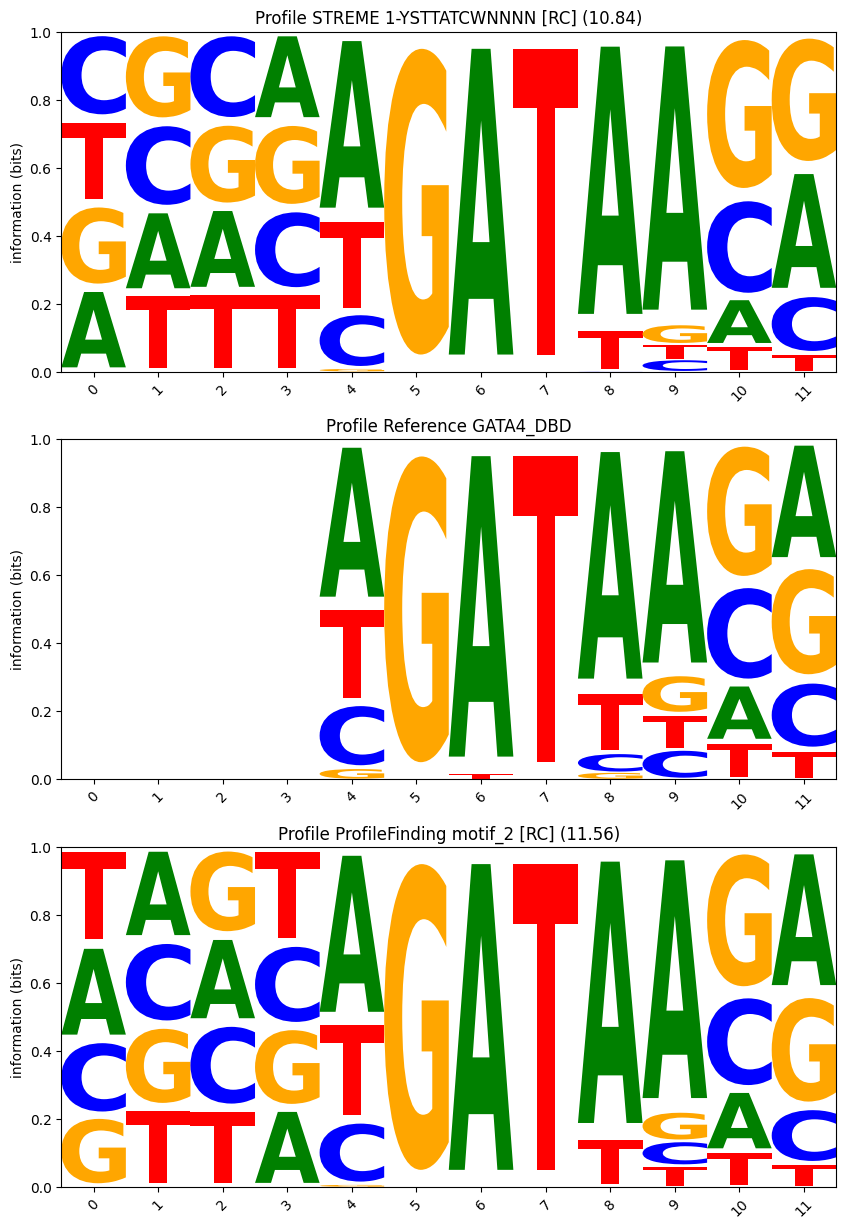

In [ ]:
compare_motifs(wd / "simulated" / "0.90" / simrefs["file"].values[0],
               simrefs["motif"].values[0], motifs, show=True)

---

In [ ]:
import random
seqlen = 100
k = 12

positions = []
for _ in range(30000):
    pos = int(random.gauss(seqlen / 2, seqlen / 12))
    pos = max(0, min(seqlen - k, pos)) # make sure pos is within bounds
    positions.append(pos)

plotting.ownPlotlyHist({'gaussian': positions},)

---

In [ ]:
assert False, "Stop here"

In [ ]:
import re
wd = Path("/home/matthis/PhD/mnt/brain/genomegraph/runs/20250424_gridsearch_STREME_vs_ProfileFinding/_test_ressource_demand")
runtimedict = {
    'name': [],
    'n_cores': [],
    'mem': [],
    'runtime': [],
}
for sd in ['full', 'half', 'third', 'quart', 'fifth', 'sixth', 'seventh', 'eigth', 'nineth', 'tenth']:
    subdir = wd / sd
    assert subdir.is_dir(), f"Subdir {subdir} does not exist"
    assert (subdir / "slurm_script.sh").is_file(), f"Slurm script {subdir / 'slurm_script.sh'} does not exist"
    # grep #SBATCH -n and #SBATCH --mem from slurm_script.sh
    with open(subdir / "slurm_script.sh", "r") as f:
        lines = f.readlines()
        for line in lines:
            if line.startswith("#SBATCH -n"):
                n_cores = int(line.split()[2])
            if line.startswith("#SBATCH --mem"):
                mem = int(line.split("=")[1])

    # grep "Job gridsearch_00000 finished in \d+ seconds" from *.out 
    slurmlogs = list(subdir.glob("*.out"))
    assert len(slurmlogs) == 1, f"Expected exactly one slurm log file in {subdir}, got {len(slurmlogs)}"
    slurmlog = slurmlogs[0]
    with open(slurmlog, "r") as f:
        lines = f.readlines()
        for line in lines:
            m = re.match(r"Job .+? finished in (\d+) seconds", line)
            if m:
                runtime = int(m.group(1))
                break
        else:
            raise ValueError(f"Could not find runtime in slurm log file {slurmlog}")


    # print(f"Subdir {sd}: {n_cores} cores, {mem} MB memory, {runtime} seconds")
    runtimedict['name'].append(sd)
    runtimedict['n_cores'].append(n_cores)
    runtimedict['mem'].append(mem)
    runtimedict['runtime'].append(runtime)

runtimes = pd.DataFrame(runtimedict)

In [ ]:
runtimes.sort_values(by='runtime', inplace=True)
runtimes

,name,n_cores,mem,runtime
1,half,36,94500,386
2,third,24,63000,394
3,quart,18,47250,399
4,fifth,14,37800,461
6,seventh,10,27000,465
7,eigth,9,23625,467
0,full,72,189000,468
5,sixth,12,15750,503
9,tenth,7,18900,940
8,nineth,8,21000,945


---

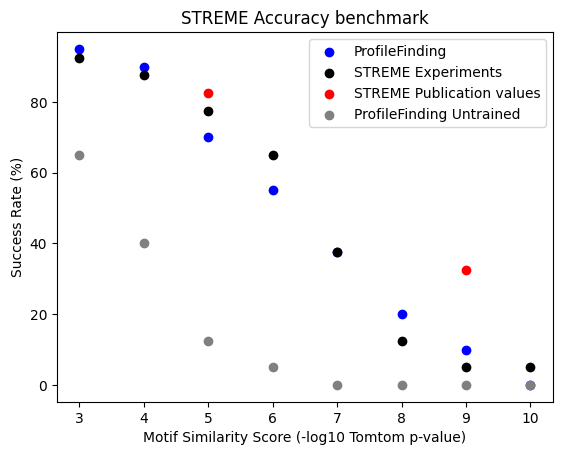

In [ ]:
fig, ax = plt.subplots(1,1)
ax.scatter(x=range(3,11),
           y=[len(ref_full[ref_full["pp-value_model"] >= i].index)*100/len(ref_full.index) for i in range(3,11)],
           marker="o",
           color="blue")
ax.scatter(x=range(3,11),
           y=[len(ref_full[ref_full["pp-value_streme"] >= i].index)*100/len(ref_full.index) for i in range(3,11)],
           marker="o",
           color="black")
ax.scatter(x=[5, 9],
           y=[82.5, 32.5],
           marker="o",
           color="red")
ax.scatter(x=range(3,11),
           y=[len(ref_full[ref_full["pp-value_model_init"] >= i].index)*100/len(ref_full.index) for i in range(3,11)],
           marker="o",
           color="grey")
ax.set_xlabel("Motif Similarity Score (-log10 Tomtom p-value)")
ax.set_ylabel("Success Rate (%)")
ax.set_title("STREME Accuracy benchmark")
# add a legend in the plot
ax.legend(["ProfileFinding", "STREME Experiments", "STREME Publication values", "ProfileFinding Untrained"])
plt.show()

In [ ]:
print(f"                   x: {range(3,11)[2]}")
print(f"STREME experiments y: {[len(ref_full[ref_full['pp-value_streme'] >= i].index)*100/len(ref_full.index) for i in range(3,11)][2]}")
print(f"ProfileFinding     y: {[len(ref_full[ref_full['pp-value_model'] >= i].index)*100/len(ref_full.index) for i in range(3,11)][2]}")

                   x: 5
STREME experiments y: 77.5
ProfileFinding     y: 70.0


Sensitivity

In [ ]:
from Bio import SeqIO

# investigate (diluted) data: 
# - are the 3-mer frequencies really conserved? (they should be)
# - in diluted primary data, are really x% of sequences conserved?

def check_kmer_conservation(prim_fa: Path, ctrl_fa: Path, k: int = 3):
    def kmer_freqs(seq, k):
        kmers = {}
        for i in range(len(seq)-k+1):
            kmer = seq[i:i+k]
            if kmer not in kmers:
                kmers[kmer] = 0
            kmers[kmer] += 1
        return kmers

    prim = list(SeqIO.parse(prim_fa, "fasta"))
    ctrl = list(SeqIO.parse(ctrl_fa, "fasta"))

    kmer_freqs_prim = kmer_freqs(prim[0].seq, 3)
    kmer_freqs_ctrl = kmer_freqs(ctrl[0].seq, 3)

    diff1 = set(kmer_freqs_prim.keys()) - set(kmer_freqs_ctrl.keys())
    diff2 = set(kmer_freqs_ctrl.keys()) - set(kmer_freqs_prim.keys())
    diff3 = [(k, kmer_freqs_prim[k], kmer_freqs_ctrl[k]) for k in kmer_freqs_prim \
                if kmer_freqs_prim[k] != kmer_freqs_ctrl[k]]

    if len(diff1) > 0 or len(diff2) > 0 or len(diff3) > 0:
        print(f"Investigating {prim_fa} and {ctrl_fa}")
        print(f"\tKmers in primary data but not in control: {diff1}")
        print(f"\tKmers in control data but not in primary: {diff2}")
        print(f"\tDiffering kmer counts: {diff3}")

for file in ref_full["file"]:
    check_kmer_conservation(datadir / "full_ds_primary" / f"{file}.centered100bp.fasta", 
                            datadir / "full_ds_control" / f"{file}.centered100bp.fasta.shuf.fasta")

In [ ]:
for purity in ["0.01", "0.02", "0.05", "0.10", "0.15", "0.20", "0.40", "0.60", "1.00"]:
    for file in ref_full["file"]:
        check_kmer_conservation(datadir / "diluted_ds_primary" / purity / f"{file}.centered100bp.{purity}pure.fasta", 
                                datadir / "diluted_ds_control" / purity / f"{file}.centered100bp.{purity}pure.shuf.fasta")


In [ ]:
for file in ref_full["file"]:
    full = list(SeqIO.parse(datadir / "full_ds_primary" / f"{file}.centered100bp.fasta", "fasta"))
    full_set = set([s.seq for s in full])
    for purity in ["0.01", "0.02", "0.05", "0.10", "0.15", "0.20", "0.40", "0.60", "1.00"][::-1]:
        diluted = list(SeqIO.parse(datadir / "diluted_ds_primary" / purity / f"{file}.centered100bp.{purity}pure.fasta",
                                   "fasta"))
        print(f"{file} {purity} {len(diluted)*100/len(full)}")
        assert len(diluted) == len(full)
        purityf = float(purity)
        ndiluted = int(len(diluted) * (1-purityf))
        equal = sum([1 for i in range(len(diluted)) if diluted[i].seq in full_set])
        #assert [s.seq for s in diluted[ndiluted:]] == [s.seq for s in full[ndiluted:]], \
        assert equal == len(diluted) - ndiluted, \
            f"Sequences are not conserved in {file} {purity=} " \
                + f"| expected {ndiluted=}, observed {equal=} diluted={(len(diluted)-ndiluted)}"

wgEncodeAwgTfbsSydhK562Atf3UniPk.narrowPeak 1.00 100.0
wgEncodeAwgTfbsSydhK562Atf3UniPk.narrowPeak 0.60 100.0
wgEncodeAwgTfbsSydhK562Atf3UniPk.narrowPeak 0.40 100.0
wgEncodeAwgTfbsSydhK562Atf3UniPk.narrowPeak 0.20 100.0
wgEncodeAwgTfbsSydhK562Atf3UniPk.narrowPeak 0.15 100.0
wgEncodeAwgTfbsSydhK562Atf3UniPk.narrowPeak 0.10 100.0
wgEncodeAwgTfbsSydhK562Atf3UniPk.narrowPeak 0.05 100.0
wgEncodeAwgTfbsSydhK562Atf3UniPk.narrowPeak 0.02 100.0
wgEncodeAwgTfbsSydhK562Atf3UniPk.narrowPeak 0.01 100.0
wgEncodeAwgTfbsHaibK562Atf3V0416101UniPk.narrowPeak 1.00 100.0
wgEncodeAwgTfbsHaibK562Atf3V0416101UniPk.narrowPeak 0.60 100.0
wgEncodeAwgTfbsHaibK562Atf3V0416101UniPk.narrowPeak 0.40 100.0
wgEncodeAwgTfbsHaibK562Atf3V0416101UniPk.narrowPeak 0.20 100.0
wgEncodeAwgTfbsHaibK562Atf3V0416101UniPk.narrowPeak 0.15 100.0
wgEncodeAwgTfbsHaibK562Atf3V0416101UniPk.narrowPeak 0.10 100.0
wgEncodeAwgTfbsHaibK562Atf3V0416101UniPk.narrowPeak 0.05 100.0
wgEncodeAwgTfbsHaibK562Atf3V0416101UniPk.narrowPeak 0.02 100.0
w

In [ ]:
import re 

# evaluate STREME sequence reordering runs (see if sequence order in input data matters)
wd_reorder = Path("/home/ebelm/genomegraph/runs/_trash/20241018_debug_STREME_diluted/full_reordered")
reorder_result = {
    'x': list(range(3,11))
}
for file in ref_full["file"]:
    repeats = sorted([d.name for d in (wd_reorder / file).iterdir() if d.is_dir() and re.match(r"\d+", d.name)])
    print(f"Processing {file}, {len(repeats)} repeats")
    reorder_result[file] = {
        'pp-value': [],
        'pp-value-same-ctrl': [],
    }
    for repeat in repeats:
        p = wd_reorder / file / repeat
        assert (p / "tomtom").exists(), f"{p / 'tomtom'} does not exist"
        resultfile = p / "tomtom/tomtom.tsv"
        assert resultfile.exists(), f"{resultfile} does not exist"

        result = pd.read_csv(resultfile, sep="\t", comment="#")
        pval = result["p-value"].min()
        # negative log10 of p-value
        ppval = -math.log10(pval)
        reorder_result[file]['pp-value'].append(ppval)

        assert (p / "original_control" / "tomtom").exists(), f"{p / 'original_control' / 'tomtom'} does not exist"
        resultfile = p / "original_control" / "tomtom/tomtom.tsv"
        assert resultfile.exists(), f"{resultfile} does not exist"

        result = pd.read_csv(resultfile, sep="\t", comment="#")
        pval = result["p-value"].min()
        # negative log10 of p-value
        ppval = -math.log10(pval)
        reorder_result[file]['pp-value-same-ctrl'].append(ppval)

Processing wgEncodeAwgTfbsSydhK562Atf3UniPk.narrowPeak, 20 repeats
Processing wgEncodeAwgTfbsHaibK562Atf3V0416101UniPk.narrowPeak, 20 repeats
Processing wgEncodeAwgTfbsSydhK562Atf106325UniPk.narrowPeak, 20 repeats
Processing wgEncodeAwgTfbsSydhK562Bhlhe40nb100IggrabUniPk.narrowPeak, 20 repeats
Processing wgEncodeAwgTfbsSydhK562CebpbIggrabUniPk.narrowPeak, 20 repeats
Processing wgEncodeAwgTfbsBroadK562CtcfUniPk.narrowPeak, 20 repeats
Processing wgEncodeAwgTfbsUwK562CtcfUniPk.narrowPeak, 20 repeats
Processing wgEncodeAwgTfbsUtaK562CtcfUniPk.narrowPeak, 20 repeats
Processing wgEncodeAwgTfbsSydhK562E2f4UcdUniPk.narrowPeak, 20 repeats
Processing wgEncodeAwgTfbsSydhK562E2f6UcdUniPk.narrowPeak, 20 repeats
Processing wgEncodeAwgTfbsHaibK562E2f6V0416102UniPk.narrowPeak, 20 repeats
Processing wgEncodeAwgTfbsHaibK562Egr1V0416101UniPk.narrowPeak, 20 repeats
Processing wgEncodeAwgTfbsHaibK562Elf1sc631V0416102UniPk.narrowPeak, 20 repeats
Processing wgEncodeAwgTfbsSydhK562Elk112771IggrabUniPk.narrowP

In [ ]:
reorder_result

{'x': [3, 4, 5, 6, 7, 8, 9, 10],
 'wgEncodeAwgTfbsSydhK562Atf3UniPk.narrowPeak': {'pp-value': [2.5188197474052894,
   nan,
   nan,
   nan,
   nan,
   nan,
   4.066802338358697,
   nan,
   nan,
   nan,
   1.011665382495725,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan],
  'pp-value-same-ctrl': [nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan,
   nan]},
 'wgEncodeAwgTfbsHaibK562Atf3V0416101UniPk.narrowPeak': {'pp-value': [8.103279826261877,
   7.785285930058005,
   8.031597380004513,
   7.835450863674223,
   7.969979453534187,
   7.96995513693385,
   7.4079265525553355,
   7.5223998378506804,
   8.007412022731762,
   8.03086143500262,
   7.394475168106899,
   7.789638668287009,
   7.8228676829582255,
   8.014173099737862,
   7.949025092055548,
   7.929267817525891,
   7.892654334527905,
   7.88817313589365,
   7.838075259778379,
   8.12463715144666],
  'pp-value-s

Order of (primary) input sequences does _not_ matter, but the background/control sequences have a great impact on the
result. The tomtom p-value can differ in over one order of magnitude for the same motif depending on the background,
STREME can also sometimes find no motif at all for the same input sequences depending on the background.

In [ ]:
from Bio import SeqIO
# investigate why diluted with 1.00 purity is different from full dataset runs
for file in ref_full["file"]:
    full_fasta = datadir / "full_ds_primary" / f"{file}.centered100bp.fasta"
    diluted_fasta = datadir / "diluted_ds_primary" / "1.00" / f"{file}.centered100bp.1.00pure.fasta"

    # parse both fastas and check if they are the same with BioPython
    full = list(SeqIO.parse(full_fasta, "fasta"))
    diluted = list(SeqIO.parse(diluted_fasta, "fasta"))
    assert len(full) == len(diluted), f"{file} has different number of sequences"
    for f, d in zip(full, diluted):
        assert f.seq == d.seq, f"{file} has different primary sequences"

    # do the same for the control seqs, they should probably be the different
    full_control = datadir / "full_ds_control" / f"{file}.centered100bp.fasta.shuf.fasta"
    diluted_control = datadir / "diluted_ds_control" / "1.00" / f"{file}.centered100bp.1.00pure.shuf.fasta"
    full = list(SeqIO.parse(full_control, "fasta"))
    diluted = list(SeqIO.parse(diluted_control, "fasta"))
    assert len(full) == len(diluted), f"{file} has different number of control sequences"
    for f, d in zip(full, diluted):
        assert f.seq != d.seq, f"{file} has the same control sequences"


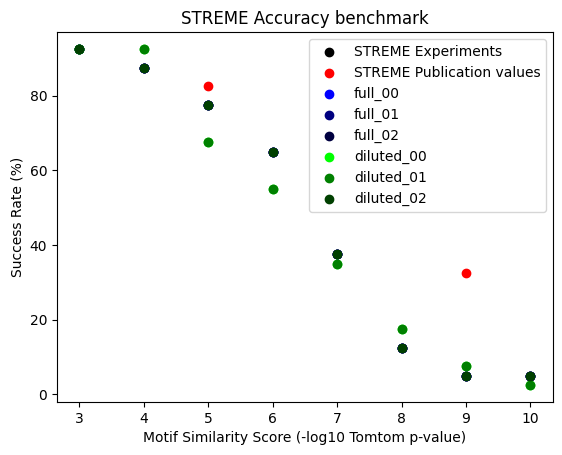

In [ ]:
# make accuracy plots of debug runs
wd_dbg = Path("/home/ebelm/genomegraph/runs/_trash/20241018_debug_STREME_diluted")
dbg_result = {}
for wd, run in [
    (wd_dbg / 'full' / '00', "full_00"), 
    (wd_dbg / 'full' / '01', "full_01"), 
    (wd_dbg / 'full_same_ctrl', "full_02"), 
    (wd_dbg / 'diluted1.00' / '00', "diluted_00"), 
    (wd_dbg / 'diluted1.00' / '01', "diluted_01"), 
    (wd_dbg / 'diluted_same_ctrl', "diluted_02")]:
    results_full = []
    for file in ref_full["file"]:
        p = wd / file
        assert p.exists(), f"{p} does not exist"
        assert (p / "tomtom").exists(), f"{p / 'tomtom'} does not exist"
        resultfile = p / "tomtom/tomtom.tsv"
        assert resultfile.exists(), f"{resultfile} does not exist"

        result = pd.read_csv(resultfile, sep="\t", comment="#")
        pval = result["p-value"].min()
        # negative log10 of p-value
        ppval = -math.log10(pval)
        results_full.append(ppval)

    dbg_result[run] = results_full

# ----

fig, ax = plt.subplots(1,1)
ax.scatter(x=range(3,11),
           y=[len(ref_full[ref_full["pp-value_streme"] >= i].index)*100/len(ref_full.index) for i in range(3,11)],
           marker="o",
           color="black")
ax.scatter(x=[5, 9],
           y=[82.5, 32.5],
           marker="o",
           color="red")
ax.scatter(x=range(3,11),
           y=[sum([1 for r in dbg_result['full_00'] if r >= i])*100/len(dbg_result['full_00']) for i in range(3,11)],
           marker="o",
           color=(0.0, 0.0, 1))
ax.scatter(x=range(3,11),
           y=[sum([1 for r in dbg_result['full_01'] if r >= i])*100/len(dbg_result['full_01']) for i in range(3,11)],
           marker="o",
           color=(0.0, 0.0, 0.5))
ax.scatter(x=range(3,11),
           y=[sum([1 for r in dbg_result['full_02'] if r >= i])*100/len(dbg_result['full_02']) for i in range(3,11)],
           marker="o",
           color=(0.0, 0.0, 0.25))
ax.scatter(x=range(3,11),
           y=[sum([1 for r in dbg_result['diluted_00'] if r >= i])*100/len(dbg_result['diluted_00']) for i in range(3,11)],
           marker="o",
           color=(0.0, 1.0, 0.0))
ax.scatter(x=range(3,11),
           y=[sum([1 for r in dbg_result['diluted_01'] if r >= i])*100/len(dbg_result['diluted_01']) for i in range(3,11)],
           marker="o",
           color=(0.0, 0.5, 0.0))
ax.scatter(x=range(3,11),
           y=[sum([1 for r in dbg_result['diluted_02'] if r >= i])*100/len(dbg_result['diluted_02']) for i in range(3,11)],
           marker="o",
           color=(0.0, 0.25, 0.0))
ax.set_xlabel("Motif Similarity Score (-log10 Tomtom p-value)")
ax.set_ylabel("Success Rate (%)")
ax.set_title("STREME Accuracy benchmark")
# add a legend in the plot
ax.legend(["STREME Experiments", "STREME Publication values", 
           "full_00", "full_01", "full_02", 
           "diluted_00", "diluted_01", "diluted_02"])
plt.show()

In [ ]:
# make accuracy plots of debug ProfileFinding runs
wd_dbg = Path("/home/ebelm/genomegraph/runs/_trash/20241022_debug_ProfileFinding_diluted/apphub")
dbg_result = {}
for wd, run in [
    (wd_dbg / 'full' / '00', "full_00"), 
    (wd_dbg / 'full' / '01', "full_01"), 
    (wd_dbg / 'diluted1.00' / '00', "diluted_00"), 
    (wd_dbg / 'diluted1.00' / '01', "diluted_01")]:
    results_full = []
    for file in ref_full["file"]:
        p = wd / file
        assert p.exists(), f"{p} does not exist"
        assert (p / "tomtom").exists(), f"{p / 'tomtom'} does not exist"
        resultfile = p / "tomtom/tomtom.tsv"
        assert resultfile.exists(), f"{resultfile} does not exist"

        result = pd.read_csv(resultfile, sep="\t", comment="#")
        pval = result["p-value"].min()
        # negative log10 of p-value
        ppval = -math.log10(pval)
        results_full.append(ppval)

    dbg_result[run] = results_full

# ----

fig, ax = plt.subplots(1,1)
ax.scatter(x=range(3,11),
           y=[len(ref_full[ref_full["pp-value_model"] >= i].index)*100/len(ref_full.index) for i in range(3,11)],
           marker="o",
           color="blue")
ax.scatter(x=[5, 9],
           y=[82.5, 32.5],
           marker="o",
           color="red")
ax.scatter(x=range(3,11),
           y=[sum([1 for r in dbg_result['full_00'] if r >= i])*100/len(dbg_result['full_00']) for i in range(3,11)],
           marker="o",
           color=(0.0, 0.0, 1))
ax.scatter(x=range(3,11),
           y=[sum([1 for r in dbg_result['full_01'] if r >= i])*100/len(dbg_result['full_01']) for i in range(3,11)],
           marker="o",
           color=(0.0, 0.0, 0.5))
ax.scatter(x=range(3,11),
           y=[sum([1 for r in dbg_result['diluted_00'] if r >= i])*100/len(dbg_result['diluted_00']) for i in range(3,11)],
           marker="o",
           color=(0.0, 1.0, 0.0))
ax.scatter(x=range(3,11),
           y=[sum([1 for r in dbg_result['diluted_01'] if r >= i])*100/len(dbg_result['diluted_01']) for i in range(3,11)],
           marker="o",
           color=(0.0, 0.5, 0.0))

ax.set_xlabel("Motif Similarity Score (-log10 Tomtom p-value)")
ax.set_ylabel("Success Rate (%)")
ax.set_title("ProfileFinding Accuracy benchmark")
# add a legend in the plot
ax.legend(["ProfileFinding Experiments", "STREME Publication values", 
           "full_00", "full_01", 
           "diluted_00", "diluted_01"])
plt.show()

AssertionError: /home/ebelm/genomegraph/runs/_trash/20241022_debug_ProfileFinding_diluted/apphub/full/00/wgEncodeAwgTfbsSydhK562Atf3UniPk.narrowPeak does not exist

In [ ]:
results_diluted = {
    'streme': {
        'purity': [],
        'success_rate': []
    },
    'model': {
        'purity': [],
        'success_rate': []
    },
    'model_init': {
        'purity': [],
        'success_rate': []
    }
}

for wd, mdl in [(wd_streme, "streme"), (wd_model, "model"), (wd_model_init, "model_init")]:
    purities = sorted([d.name for d in (wd / 'diluted').iterdir() if d.is_dir() and d.name != "logs"])
    print(f"{purities=}")
    for purity in purities:
        results_diluted[mdl]['purity'].append(int(float(purity)*100))
        ny = 0
        for file in ref_full["file"]:
            p = wd / "diluted" / purity / file
            assert p.exists(), f"{p} does not exist"
            if not (p / "tomtom").exists():
                print(f"[WARNING] >>> {p / 'tomtom'} does not exist")
                continue

            resultfile = p / "tomtom/tomtom.tsv"
            assert resultfile.exists(), f"{resultfile} does not exist"

            #print(f"[DEBUG] >>> [{mdl=}] {resultfile}")
            result = pd.read_csv(resultfile, sep="\t", comment="#")
            pval = result["p-value"].min()
            # negative log10 of p-value
            ppval = -math.log10(pval)
            if ppval >= 5:
                ny += 1

        results_diluted[mdl]['success_rate'].append(ny*100/len(ref_full.index))

purities=['0.01', '0.02', '0.05', '0.10', '0.15', '0.20', '0.40', '0.60', '1.00']
purities=['0.01', '0.02', '0.05', '0.10', '0.15', '0.20', '0.40', '0.60', '1.00']
purities=['0.01', '0.02', '0.05', '0.10', '0.15', '0.20', '0.40', '0.60', '1.00']


In [ ]:
# also add ProfileFinding results with finer dilution steps

purities = sorted([d.name for d in (wd_model / 'diluted_custom').iterdir() if d.is_dir() and d.name != "logs"])
print(f"{purities=}")
for purity in purities:
    results_diluted["model"]['purity'].append(int(float(purity)*100))
    ny = 0
    for file in ref_full["file"]:
        p = wd_model / "diluted_custom" / purity / file
        assert p.exists(), f"{p} does not exist"
        if not (p / "tomtom").exists():
            print(f"[WARNING] >>> {p / 'tomtom'} does not exist")
            continue

        resultfile = p / "tomtom/tomtom.tsv"
        assert resultfile.exists(), f"{resultfile} does not exist"

        #print(f"[DEBUG] >>> [model] {resultfile}")
        result = pd.read_csv(resultfile, sep="\t", comment="#")
        pval = result["p-value"].min()
        # negative log10 of p-value
        ppval = -math.log10(pval)
        if ppval >= 5:
            ny += 1

    results_diluted["model"]['success_rate'].append(ny*100/len(ref_full.index))

purities=['0.70', '0.80', '0.90', '0.95']


In [ ]:
results_diluted

{'streme': {'purity': [1, 2, 5, 10, 15, 20, 40, 60, 100],
  'success_rate': [0.0, 5.0, 37.5, 52.5, 62.5, 77.5, 72.5, 72.5, 67.5]},
 'model': {'purity': [1, 2, 5, 10, 15, 20, 40, 60, 100, 70, 80, 90, 95],
  'success_rate': [0.0,
   0.0,
   2.5,
   2.5,
   0.0,
   0.0,
   0.0,
   2.5,
   70.0,
   5.0,
   12.5,
   15.0,
   22.5]},
 'model_init': {'purity': [1, 2, 5, 10, 15, 20, 40, 60, 100],
  'success_rate': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 12.5]}}

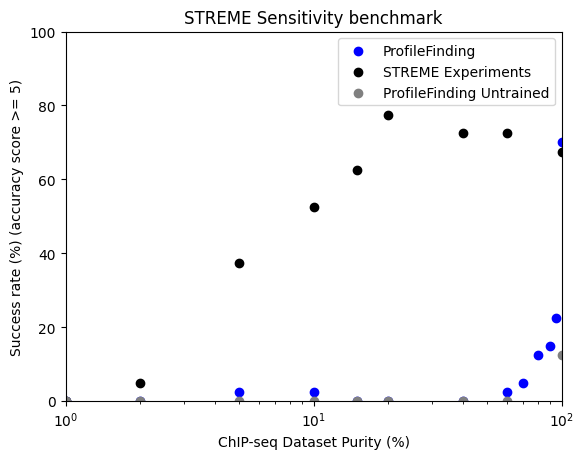

In [ ]:
fig, ax = plt.subplots(1,1)
ax.scatter(x=results_diluted['model']['purity'],
           y=results_diluted['model']['success_rate'],
           marker="o",
           color="blue")
ax.scatter(x=results_diluted['streme']['purity'],
           y=results_diluted['streme']['success_rate'],
           marker="o",
           color="black")
ax.scatter(x=results_diluted['model_init']['purity'],
           y=results_diluted['model_init']['success_rate'],
           marker="o",
           color="grey")
ax.set_xlabel("ChIP-seq Dataset Purity (%)")
ax.set_ylabel("Success rate (%) (accuracy score >= 5)")
ax.set_xscale("log")
ax.set_xlim(1, 100)
ax.set_ylim(0, 100)
ax.set_title("STREME Sensitivity benchmark")
# add a legend in the plot
ax.legend(["ProfileFinding", "STREME Experiments", "ProfileFinding Untrained"])
plt.show()

In [ ]:
print(f"                   x: {results_diluted['model']['purity'][-1]}")
print(f"STREME experiments y: {results_diluted['streme']['success_rate'][-1]}")
print(f"ProfileFinding     y: {results_diluted['model']['success_rate'][-1]}")

                   x: 100
STREME experiments y: 67.5
ProfileFinding     y: 70.0


In [ ]:
import os
for dil in sorted((wd_model / "diluted" ).iterdir()):
    if not dil.is_dir() or dil.name == "logs":
        continue
    
    #print(f"{dil.name=}")
    nmotifs = 0
    for file in ref_full["file"]:
        p = dil / file
        assert p.exists(), f"{p} does not exist"
        if not (p / "tomtom").exists():
            print(f"[WARNING] >>> {p / 'tomtom'} does not exist")
            continue

        resultfile = p / "tomtom/tomtom.tsv"
        assert resultfile.exists(), f"{resultfile} does not exist"

        #print(f"[DEBUG] >>> [{mdl=}] {resultfile}")
        result = pd.read_csv(resultfile, sep="\t", comment="#")
        if len(result.index) > 0:
            nmotifs += 1
        # if len(result.index) == 0:
        #     print(f"{dil.name=} {file=} {resultfile} has no results")
        # else:
        #     # run make_tomtom.doc
        #     assert (p / "make_tomtom.doc").exists(), f"{p / 'make_tomtom.doc'} does not exist"
        #     os.system(f"bash {str(p)}/make_tomtom.doc")

    print(f"{dil.name} % data set purity: {nmotifs=}/{len(ref_full.index)}")

0.01 % data set purity: nmotifs=20/40
0.02 % data set purity: nmotifs=20/40
0.05 % data set purity: nmotifs=21/40
0.10 % data set purity: nmotifs=20/40
0.15 % data set purity: nmotifs=18/40
0.20 % data set purity: nmotifs=23/40
0.40 % data set purity: nmotifs=22/40
0.60 % data set purity: nmotifs=22/40
1.00 % data set purity: nmotifs=39/40


Thoroughness

In [ ]:
results_hybrid = {
    'streme': {
        'pp_thresh': list(range(3,11)),
        'avg_success_rate': [],
        'std_success_rate': [],
    },
    'model': {
        'pp_thresh': list(range(3,11)),
        'avg_success_rate': [],
        'std_success_rate': [],
    },
    'model_init': {
        'pp_thresh': list(range(3,11)),
        'avg_success_rate': [],
        'std_success_rate': [],
    }
}

for wd, mdl in [(wd_streme, "streme"), (wd_model, "model"), (wd_model_init, "model_init")]:
    iterations = sorted([d.name for d in (wd / 'hybrid').iterdir() if d.is_dir()])
    print(f"{iterations=}")

    for pp_t in results_hybrid[mdl]['pp_thresh']:
        rates = []
        for it in iterations:
            ny = 0
            for file in ref_hyb["file"]:
                p = wd / "hybrid" / it / file
                assert p.exists(), f"{p} does not exist"
                assert (p / "tomtom").exists(), f"{p / 'tomtom'} does not exist"
                resultfile = p / "tomtom/tomtom.tsv"
                assert resultfile.exists(), f"{resultfile} does not exist"

                result = pd.read_csv(resultfile, sep="\t", comment="#")
                pval = result["p-value"].min()
                # negative log10 of p-value
                ppval = -math.log10(pval)
                if ppval >= pp_t:
                    ny += 1

            rates.append(ny*100/len(ref_hyb.index))

        results_hybrid[mdl]['avg_success_rate'].append(sum(rates)/len(rates))
        results_hybrid[mdl]['std_success_rate'].append(math.sqrt(sum([(r - results_hybrid[mdl]['avg_success_rate'][-1])**2 for r in rates])/len(rates)))

iterations=['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19']
iterations=['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19']
iterations=['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19']


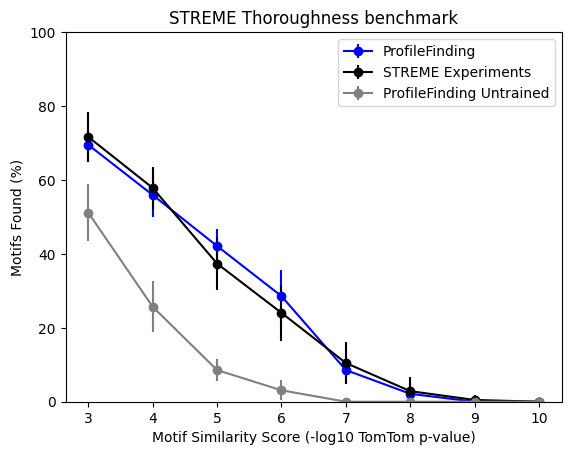

In [ ]:
fig, ax = plt.subplots(1,1)
ax.errorbar(x=results_hybrid['model']['pp_thresh'],
           y=results_hybrid['model']['avg_success_rate'],
           marker="o",
           yerr=results_hybrid['model']['std_success_rate'],
           color="blue")
ax.errorbar(x=results_hybrid['streme']['pp_thresh'],
           y=results_hybrid['streme']['avg_success_rate'],
           marker="o",
           yerr=results_hybrid['streme']['std_success_rate'],
           color="black")
ax.errorbar(x=results_hybrid['model_init']['pp_thresh'],
            y=results_hybrid['model_init']['avg_success_rate'],
            marker="o",
            yerr=results_hybrid['model_init']['std_success_rate'],
            color="grey")
ax.set_xlabel("Motif Similarity Score (-log10 TomTom p-value)")
ax.set_ylabel("Motifs Found (%)")
ax.set_ylim(0, 100)
ax.set_title("STREME Thoroughness benchmark")
# add a legend in the plot
ax.legend(["ProfileFinding", "STREME Experiments", "ProfileFinding Untrained"])
plt.show()

---

Evaluate deviation of multiple STREME and ProfileFinding runs on the same data

In [ ]:
wd_streme_std = Path("/home/ebelm/genomegraph/runs/20240903_replicate_STREME_results/full_repeat")
wd_model_std = Path("/home/ebelm/genomegraph/runs/20241008_model_on_STREME_data/full_repeat")

In [ ]:
results_full_std = {
    'streme': {
        'pp_thresh': list(range(3,11)),
        'avg_success_rate': [],
        'std_success_rate': [],
        'max_success_rate': [],
        'min_success_rate': [],
    },
    'model': {
        'pp_thresh': list(range(3,11)),
        'avg_success_rate': [],
        'std_success_rate': [],
        'max_success_rate': [],
        'min_success_rate': [],
    },
}

for wd, mdl in [(wd_streme_std, "streme"), (wd_model_std, "model")]:
    iterations = sorted([d.name for d in wd.iterdir() if d.is_dir() and d.name != "logs"])
    print(f"{iterations=}")

    for pp_t in results_full_std[mdl]['pp_thresh']:
        rates = []
        for it in iterations:
            ny = 0
            for file in ref_full["file"]:
                p = wd / it / file
                assert p.exists(), f"{p} does not exist"
                assert (p / "tomtom").exists(), f"{p / 'tomtom'} does not exist"
                resultfile = p / "tomtom/tomtom.tsv"
                assert resultfile.exists(), f"{resultfile} does not exist"

                result = pd.read_csv(resultfile, sep="\t", comment="#")
                pval = result["p-value"].min()
                # negative log10 of p-value
                ppval = -math.log10(pval)
                if ppval >= pp_t:
                    ny += 1

            rates.append(ny*100/len(ref_full.index))

        results_full_std[mdl]['avg_success_rate'].append(statistics.mean(rates))
        results_full_std[mdl]['std_success_rate'].append(statistics.stdev(rates))
        results_full_std[mdl]['max_success_rate'].append(max(rates))
        results_full_std[mdl]['min_success_rate'].append(min(rates))
        

        

iterations=['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '4', '5', '6', '7', '8', '9']
iterations=['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '4', '5', '6', '7', '8', '9']


In [ ]:
results_full_std

{'streme': {'pp_thresh': [3, 4, 5, 6, 7, 8, 9, 10],
  'avg_success_rate': [93.21428571428571,
   89.76190476190476,
   75.11904761904762,
   60.833333333333336,
   39.523809523809526,
   17.023809523809526,
   6.904761904761905,
   2.142857142857143],
  'std_success_rate': [1.1572751247156894,
   2.7277236279499046,
   2.4336431635757627,
   2.993047499344662,
   3.4112907765103757,
   2.5762190826683904,
   2.222718198619922,
   1.8175729499999247],
  'max_success_rate': [95.0, 95.0, 80.0, 65.0, 47.5, 25.0, 10.0, 5.0],
  'min_success_rate': [92.5, 85.0, 70.0, 55.0, 35.0, 15.0, 2.5, 0.0]},
 'model': {'pp_thresh': [3, 4, 5, 6, 7, 8, 9, 10],
  'avg_success_rate': [95.0, 90.0, 70.0, 55.0, 37.5, 20.0, 10.0, 0.0],
  'std_success_rate': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  'max_success_rate': [95.0, 90.0, 70.0, 55.0, 37.5, 20.0, 10.0, 0.0],
  'min_success_rate': [95.0, 90.0, 70.0, 55.0, 37.5, 20.0, 10.0, 0.0]}}

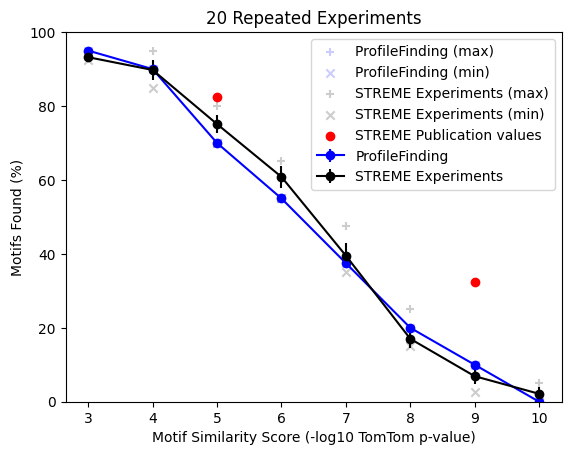

In [ ]:
fig, ax = plt.subplots(1,1)
ax.errorbar(x=results_full_std['model']['pp_thresh'],
            y=results_full_std['model']['avg_success_rate'],
            marker="o",
            yerr=results_full_std['model']['std_success_rate'],
            color="blue")
ax.scatter(x=results_full_std['model']['pp_thresh'],
           y=results_full_std['model']['max_success_rate'],
           marker="+",
           color=(0,0,1,0.2))
ax.scatter(x=results_full_std['model']['pp_thresh'],
           y=results_full_std['model']['min_success_rate'],
           marker="x",
           color=(0,0,1,0.2))
ax.errorbar(x=results_full_std['streme']['pp_thresh'],
            y=results_full_std['streme']['avg_success_rate'],
            marker="o",
            yerr=results_full_std['streme']['std_success_rate'],
            color="black")
ax.scatter(x=results_full_std['streme']['pp_thresh'],
           y=results_full_std['streme']['max_success_rate'],
           marker="+",
           color=(0,0,0,0.2))
ax.scatter(x=results_full_std['streme']['pp_thresh'],
           y=results_full_std['streme']['min_success_rate'],
           marker="x",
           color=(0,0,0,0.2))
ax.scatter(x=[5, 9],
           y=[82.5, 32.5],
           marker="o",
           color="red")

ax.set_xlabel("Motif Similarity Score (-log10 TomTom p-value)")
ax.set_ylabel("Motifs Found (%)")
ax.set_ylim(0, 100)
ax.set_title("20 Repeated Experiments")
# add a legend in the plot
ax.legend(["ProfileFinding (max)", "ProfileFinding (min)", "STREME Experiments (max)", "STREME Experiments (min)", "STREME Publication values", "ProfileFinding", "STREME Experiments"])
plt.show()